In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import pearsonr

In [2]:
file_name = 'NEXT DATA CALCULATED FINAL TO BE USED.xlsx'

data = pd.read_excel(
    file_name,
    sheet_name='MAIN DATASET')
data.head()

,FY,Retail sales reported £m,RETAIL SALES INDEX,Online/Directory sales reported £m,ONLINE SALE INDEX,Total Retail + Online/Directory sales £m,Retail operating profit £m,RETAIL PROFIT INDEX,Online/Directory operating profit £m,ONLINE PROFIT CONTRIBUTION%,...,NEXT Group PBT Margin APM %,Group PBT margin %,COVID DUMMY,53 WEEK FLAG,POST IFRS16 DUMMY,Group Distribution Costs £m,Group Distribution Cost Intensity %,Distribution Cost to Online Sales %,Notes/source basis,Column1
0,2015,2348.2,100.000000,1540.6,100.000000,3888.8,383.8,100.000000,376.8,49.539837,...,19.420031,19.555978,0,0,0,322.9,8.072904,20.959366,FY2015 comparator from FY2016 annual report; f...,NaN
1,2016,2373.5,101.077421,1658.7,107.665844,4032.2,402.1,104.768108,405.2,50.191998,...,19.791792,19.662908,0,1,0,351.6,8.417726,21.197323,FY2016 comparator from FY2017 annual report; s...,NaN
2,2017,2304.6,98.143259,1728.5,112.196547,4033.1,353.3,92.053153,429.5,54.867144,...,19.101721,19.285871,0,0,0,345.1,8.422620,19.965288,FY2017 restated comparator from FY2018 annual ...,NaN
3,2018,2123.0,90.409675,1672.4,108.555108,3795.4,268.7,70.010422,309.8,53.552290,...,17.634487,17.750018,0,0,0,399.7,9.770944,23.899785,FY2018 restated/reclassified comparator from F...,NaN
4,2019,1955.1,83.259518,1918.8,124.548877,3873.9,212.3,55.315268,352.6,62.418127,...,17.380180,17.603302,0,0,1,457.5,10.978068,23.843027,FY2019 comparator from FY2020 annual report; f...,NaN


In [3]:
data['FY'] = pd.to_numeric(
    data['FY'],
    errors='coerce')

data = data[
    (data['FY'] >= 2015) &
    (data['FY'] <= 2026) &
    (data['NEXT Group PBT Margin APM %'].notna())].copy()
data['FY'] = data['FY'].astype(int)
data = data.sort_values('FY').reset_index(drop=True)

print('Number of observations:', len(data))
print('First year:', data['FY'].min())
print('Final year:', data['FY'].max())

Number of observations: 12
First year: 2015
Final year: 2026


Make the main columns numeric

In [4]:
numeric_columns = [
    'Retail sales reported £m',
    'Online/Directory sales reported £m',
    'Retail operating profit £m',
    'Online/Directory operating profit £m',
    'Statutory Revenue £m',
    'NEXT Group PBT (APM £m)',
    'Total Group Sales (APM £m)',
    'Retail sales share %',
    'Online/Directory sales share %',
    'Retail profit margin %',
    'Online/Directory profit margin %',
    'NEXT Group PBT Margin APM %',
    'Retail store count',
    'Group Distribution Costs £m',
    'Group Distribution Cost Intensity %']

data[numeric_columns] = data[numeric_columns].apply(
    pd.to_numeric,
    errors='coerce')

In [5]:
data[numeric_columns].isnull().sum()

,0
Retail sales reported £m,0
Online/Directory sales reported £m,0
Retail operating profit £m,0
Online/Directory operating profit £m,0
Statutory Revenue £m,0
NEXT Group PBT (APM £m),0
Total Group Sales (APM £m),0
Retail sales share %,0
Online/Directory sales share %,0
Retail profit margin %,0


In [6]:
recalculated_apm_margin = (
    data['NEXT Group PBT (APM £m)']
    / data['Total Group Sales (APM £m)']) * 100

maximum_difference = (
    data['NEXT Group PBT Margin APM %']
    - recalculated_apm_margin).abs().max()

print(
    'Maximum difference:',
    round(maximum_difference, 6))

assert maximum_difference < 0.01, (
    'APM margin does not match PBT divided by Total Group Sales')

Maximum difference: 0.0


Display structural-break years

In [7]:
break_years = [2018, 2020, 2021, 2023, 2026]

structural_breaks = data.loc[
    data['FY'].isin(break_years),
    ['FY', 'Notes/source basis']]

structural_breaks

,FY,Notes/source basis
3,2018,FY2018 restated/reclassified comparator from F...
5,2020,FY2020 restated comparator; profit figures use...
6,2021,COVID-disrupted 53-week year. Stores closed fo...
8,2023,FY2023 restated comparator from FY2024 report;...
11,2026,FY2026 actual figures from Jan 2026 annual rep...


In [8]:

data['Years since 2015'] = data['FY'] - 2015

break_2018_column = []
break_2023_column = []

for year in data['FY']:
    if year >= 2018:
        break_2018_column.append(1)
    else:
        break_2018_column.append(0)
    if year >= 2023:
        break_2023_column.append(1)
    else:
        break_2023_column.append(0)

data['Break 2018'] = break_2018_column
data['Break 2023'] = break_2023_column

In [9]:
data = data.drop(
    columns=['Group PBT margin %'],
    errors='ignore')

Objective 1: Analyse the sales-channel shift

Compare FY2015 and FY2026 sales

In [10]:
sales_start_end = data.loc[
    data['FY'].isin([2015, 2026]),
    ['FY',
      'Retail sales reported £m',
      'Online/Directory sales reported £m',
      'Retail sales share %',
      'Online/Directory sales share %']]
sales_start_end.round(2)

,FY,Retail sales reported £m,Online/Directory sales reported £m,Retail sales share %,Online/Directory sales share %
0,2015,2348.2,1540.6,60.38,39.62
11,2026,1893.0,4097.0,31.60,68.40


Plot Retail and Online/Directory sales

This graph shows actual sales values in £million.

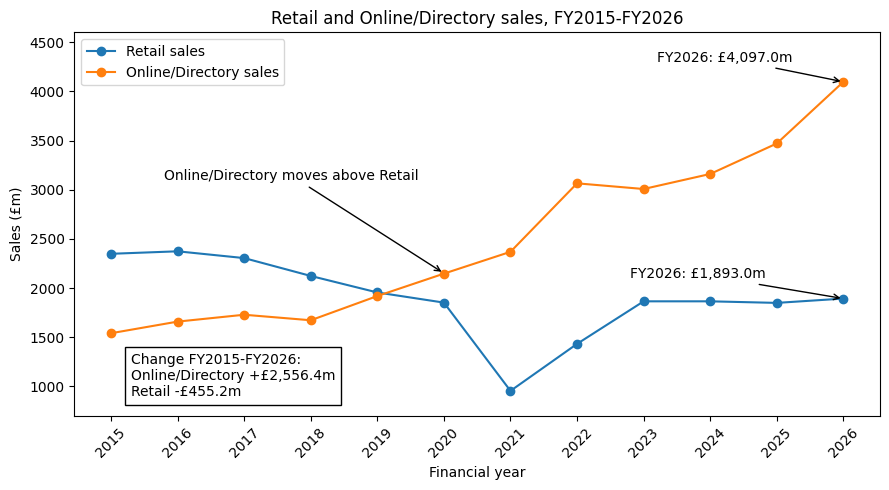

In [11]:
plt.figure(figsize=(9, 5))

plt.plot(
    data['FY'],
    data['Retail sales reported £m'],
    marker='o',
    label='Retail sales')

plt.plot(
    data['FY'],
    data['Online/Directory sales reported £m'],
    marker='o',
    label='Online/Directory sales')

plt.title('Retail and Online/Directory sales, FY2015-FY2026')
plt.xlabel('Financial year')
plt.ylabel('Sales (£m)')


plt.ylim(700, 4600)
plt.annotate(
    'FY2026: £4,097.0m',
    xy=(2026, 4097.0),
    xytext=(2023.2, 4300),
    arrowprops=dict(arrowstyle='->'))

plt.annotate(
    'FY2026: £1,893.0m',
    xy=(2026, 1893.0),
    xytext=(2022.8, 2100),
    arrowprops=dict(arrowstyle='->'))

plt.annotate(
    'Online/Directory moves above Retail',
    xy=(2020, 2150),
    xytext=(2015.8, 3100),
    arrowprops=dict(arrowstyle='->'))


plt.text(
    2015.3,
    900,
    'Change FY2015-FY2026:\nOnline/Directory +£2,556.4m\nRetail -£455.2m',
    bbox=dict(facecolor='white', edgecolor='black'))

plt.xticks(data['FY'], rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig(
    'Figure_4_1_segment_sales.png',
    dpi=300)

plt.show()

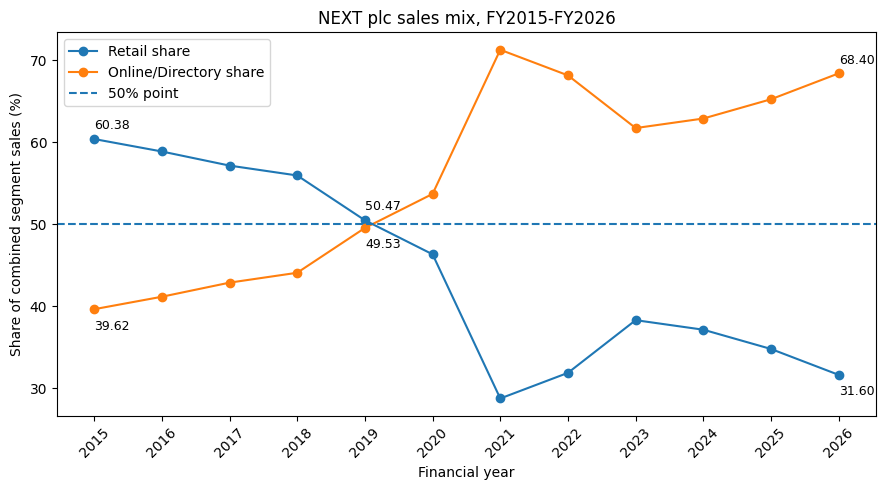

In [12]:
# calculate sales shares
retail_share = (
    data['Retail sales reported £m'] /
    (data['Retail sales reported £m'] + data['Online/Directory sales reported £m'])) * 100

online_share = (
    data['Online/Directory sales reported £m'] /
    (data['Retail sales reported £m'] + data['Online/Directory sales reported £m'])) * 100

plt.figure(figsize=(9, 5))

plt.plot(data['FY'], retail_share, marker='o', label='Retail share')
plt.plot(data['FY'], online_share, marker='o', label='Online/Directory share')
plt.axhline(50, linestyle='--', label='50% point')

plt.title('NEXT plc sales mix, FY2015-FY2026')
plt.xlabel('Financial year')
plt.ylabel('Share of combined segment sales (%)')


plt.text(2015, retail_share.iloc[0] + 1.2, f'{retail_share.iloc[0]:.2f}', fontsize=9)
plt.text(2015, online_share.iloc[0] - 2.5, f'{online_share.iloc[0]:.2f}', fontsize=9)

plt.text(2019, retail_share.iloc[4] + 1.2, f'{retail_share.iloc[4]:.2f}', fontsize=9)
plt.text(2019, online_share.iloc[4] - 2.5, f'{online_share.iloc[4]:.2f}', fontsize=9)

plt.text(2026, retail_share.iloc[-1] - 2.5, f'{retail_share.iloc[-1]:.2f}', fontsize=9)
plt.text(2026, online_share.iloc[-1] + 1.2, f'{online_share.iloc[-1]:.2f}', fontsize=9)

plt.xticks(data['FY'], rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig('Figure_4_2_sales_mix_share.png', dpi=300)
plt.show()

Plot Retail and Online sales shares

This graph shows the changing channel composition.

Objective 2: Compare segment profitability

Creating the profitability table

In [13]:
profitability_table = data[
    ['FY','Retail operating profit £m',
        'Online/Directory operating profit £m',
        'Retail profit margin %',
        'Online/Directory profit margin %',
        'NEXT Group PBT Margin APM %']]
profitability_table.round(2)

,FY,Retail operating profit £m,Online/Directory operating profit £m,Retail profit margin %,Online/Directory profit margin %,NEXT Group PBT Margin APM %
0,2015,383.8,376.8,16.34,24.46,19.42
1,2016,402.1,405.2,16.94,24.43,19.79
2,2017,353.3,429.5,15.33,24.85,19.10
3,2018,268.7,309.8,12.66,18.52,17.63
4,2019,212.3,352.6,10.86,18.38,17.38
5,2020,234.0,417.3,12.64,19.44,17.16
6,2021,-136.3,476.5,-14.28,20.12,9.44
7,2022,107.0,604.4,7.47,19.72,16.93
8,2023,240.0,467.0,12.87,15.53,15.86
9,2024,245.0,517.0,13.14,16.36,15.71


Plot Retail and Online operating profit

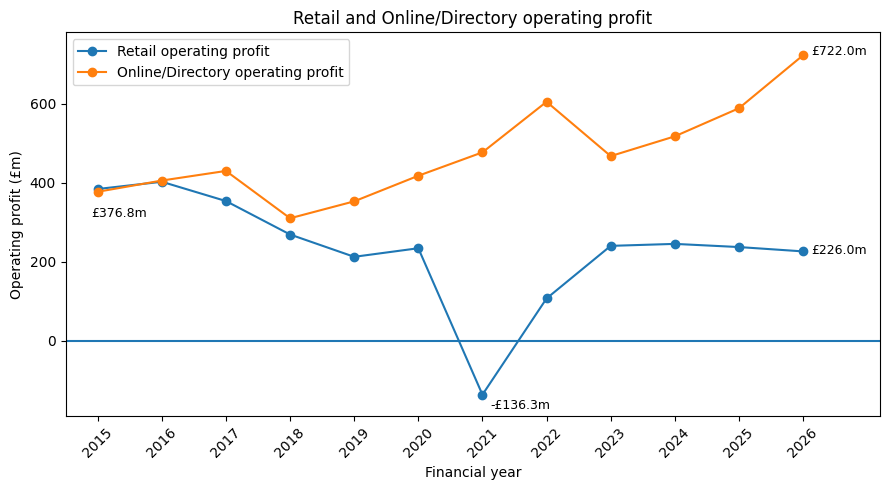

In [14]:
plt.figure(figsize=(9, 5))

plt.plot(
    data['FY'],
    data['Retail operating profit £m'],
    marker='o',
    label='Retail operating profit')

plt.plot(
    data['FY'],
    data['Online/Directory operating profit £m'],
    marker='o',
    label='Online/Directory operating profit')

plt.axhline(0)

plt.title('Retail and Online/Directory operating profit')
plt.xlabel('Financial year')
plt.ylabel('Operating profit (£m)')


plt.xlim(2014.5, 2027.2)
plt.ylim(-190, 780)


plt.annotate(
    '£376.8m',
    xy=(2015, 376.8),
    xytext=(-5, -18),
    textcoords='offset points',
    fontsize=9)

plt.annotate(
    '£722.0m',
    xy=(2026, 722.0),
    xytext=(6, 0),
    textcoords='offset points',
    fontsize=9)

plt.annotate(
    '-£136.3m',
    xy=(2021, -136.3),
    xytext=(6, -10),
    textcoords='offset points',
    fontsize=9)

plt.annotate(
    '£226.0m',
    xy=(2026, 226.0),
    xytext=(6, -2),
    textcoords='offset points',
    fontsize=9)

plt.xticks(data['FY'], rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig('Figure_4_3_segment_profit.png', dpi=300)
plt.show()

Plot the segment profit margins

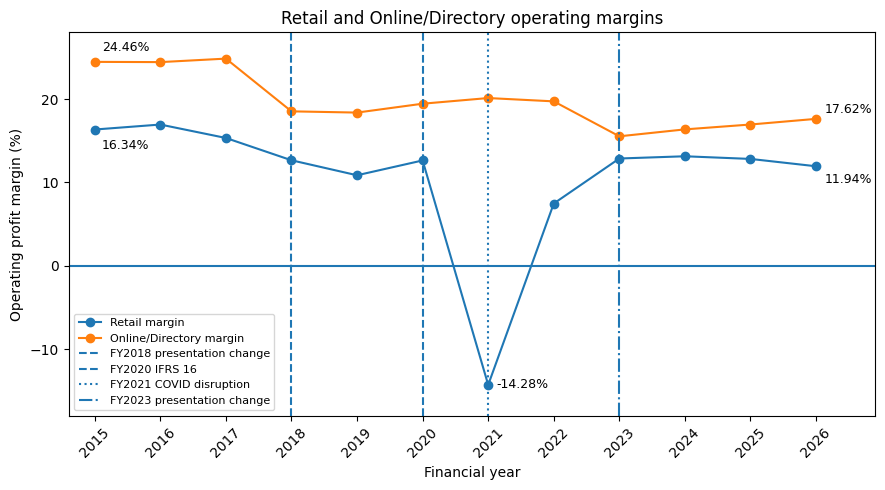

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    data['FY'],
    data['Retail profit margin %'],
    marker='o',
    label='Retail margin')

plt.plot(
    data['FY'],
    data['Online/Directory profit margin %'],
    marker='o',
    label='Online/Directory margin')

plt.axhline(0)

# reporting break lines
plt.axvline(2018, linestyle='--', label='FY2018 presentation change')
plt.axvline(2020, linestyle='--', label='FY2020 IFRS 16')
plt.axvline(2021, linestyle=':', label='FY2021 COVID disruption')
plt.axvline(2023, linestyle='-.', label='FY2023 presentation change')

plt.title('Retail and Online/Directory operating margins')
plt.xlabel('Financial year')
plt.ylabel('Operating profit margin (%)')


plt.xlim(2014.6, 2026.9)
plt.ylim(-18, 28)


plt.annotate(
    '24.46%',
    xy=(2015, 24.46),
    xytext=(5, 8),
    textcoords='offset points',
    fontsize=9)

plt.annotate(
    '17.62%',
    xy=(2026, 17.62),
    xytext=(6, 4),
    textcoords='offset points',
    fontsize=9)

plt.annotate(
    '16.34%',
    xy=(2015, 16.34),
    xytext=(5, -14),
    textcoords='offset points',
    fontsize=9)

plt.annotate(
    '11.94%',
    xy=(2026, 11.94),
    xytext=(6, -12),
    textcoords='offset points',
    fontsize=9)

plt.annotate(
    '-14.28%',
    xy=(2021, -14.28),
    xytext=(6, -2),
    textcoords='offset points',
    fontsize=9)

plt.xticks(data['FY'], rotation=45)
plt.legend(fontsize=8)
plt.tight_layout()

plt.savefig('Figure_4_4_segment_margins.png', dpi=300)
plt.show()

##dummy variable regression for structural breaks

In [16]:
y = data['Online/Directory profit margin %']

X_naive = sm.add_constant(data[['Years since 2015']])
model_naive = sm.OLS(y, X_naive).fit()

X_adjusted = sm.add_constant(data[['Years since 2015', 'Break 2018', 'Break 2023']])
model_adjusted = sm.OLS(y, X_adjusted).fit()


In [17]:
print('Naive trend, nothing controlled')
print('   slope', round(model_naive.params['Years since 2015'], 3),
      'pp per year   p', round(model_naive.pvalues['Years since 2015'], 4),
      '  R2', round(model_naive.rsquared, 3))

Naive trend, nothing controlled
   slope -0.742 pp per year   p 0.0009   R2 0.683


In [18]:
print()
print('Trend after the two reporting breaks are removed')
print('slope', round(model_adjusted.params['Years since 2015'], 3),
      'pp per year   p', round(model_adjusted.pvalues['Years since 2015'], 4),
      '  R2', round(model_adjusted.rsquared, 3))


Trend after the two reporting breaks are removed
slope 0.468 pp per year   p 0.0007   R2 0.991


In [19]:
print('   FY2018 level shift', round(model_adjusted.params['Break 2018'], 2), 'pp')
print('   FY2023 level shift', round(model_adjusted.params['Break 2023'], 2), 'pp')

   FY2018 level shift -7.21 pp
   FY2023 level shift -4.73 pp


In [20]:
first_margin = data['Online/Directory profit margin %'].iloc[0]
last_margin = data['Online/Directory profit margin %'].iloc[-1]
observed_change = last_margin - first_margin

shift_2018 = model_adjusted.params['Break 2018']
shift_2023 = model_adjusted.params['Break 2023']
underlying = model_adjusted.params['Years since 2015'] * 11


In [21]:
print('Observed Online margin change FY2015 to FY2026:', round(observed_change, 2), 'pp')
print('Explained by FY2018 reclassification:', round(shift_2018, 2), 'pp')
print('Explained by FY2023 reclassification:', round(shift_2023, 2), 'pp')
print('Underlying trading trend over eleven years:', round(underlying, 2), 'pp')

Observed Online margin change FY2015 to FY2026: -6.84 pp
Explained by FY2018 reclassification: -7.21 pp
Explained by FY2023 reclassification: -4.73 pp
Underlying trading trend over eleven years: 5.15 pp


Calculating annual Online-margin changes

This calculates the movement from one year to the next.

In [22]:
data['Online margin annual change'] = data[
    'Online/Directory profit margin %'].diff()
online_margin_change = data[
    ['FY','Online/Directory profit margin %','Online margin annual change']]

online_margin_change.round(2)

,FY,Online/Directory profit margin %,Online margin annual change
0,2015,24.46,NaN
1,2016,24.43,-0.03
2,2017,24.85,0.42
3,2018,18.52,-6.32
4,2019,18.38,-0.15
5,2020,19.44,1.06
6,2021,20.12,0.68
7,2022,19.72,-0.40
8,2023,15.53,-4.19
9,2024,16.36,0.83


Plotting annual Online-margin changes

This helps identify whether the full-period decline was spread across all years or concentrated around reporting-change years.

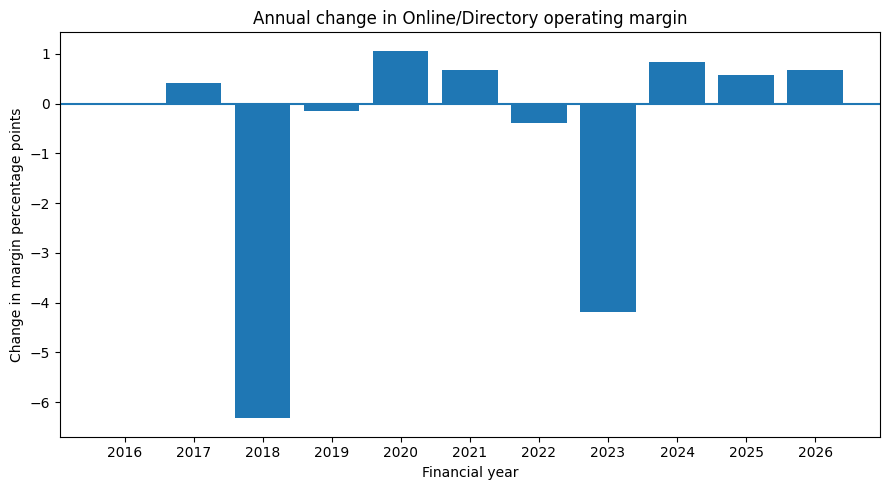

In [23]:
plt.figure(figsize=(9, 5))

plt.bar(
    data['FY'].astype(str),
    data['Online margin annual change'])
plt.axhline(0)
plt.title('Annual change in Online/Directory operating margin')
plt.xlabel('Financial year')
plt.ylabel('Change in margin percentage points')
plt.tight_layout()
plt.savefig(
    'Figure_4_5_online_margin_change.png',
    dpi=300)
plt.show()

Did Online profit compensate for Retail decline?

Calculating the change in each segment’s profit

# Comparing each segment's profit with its FY2015 level to see whether Online profit growth offset the Retail profit decline over time.

In [24]:
compensation = data[
    ['FY']].copy()

compensation['Retail profit change £m'] = (
    data['Retail operating profit £m']
    - data['Retail operating profit £m'].iloc[0])

compensation['Online profit change £m'] = (
    data['Online/Directory operating profit £m']
    - data['Online/Directory operating profit £m'].iloc[0])

compensation['Combined profit change £m'] = (
    compensation['Retail profit change £m']
    + compensation['Online profit change £m'])

compensation.round(2)

,FY,Retail profit change £m,Online profit change £m,Combined profit change £m
0,2015,0.0,0.0,0.0
1,2016,18.3,28.4,46.7
2,2017,-30.5,52.7,22.2
3,2018,-115.1,-67.0,-182.1
4,2019,-171.5,-24.2,-195.7
5,2020,-149.8,40.5,-109.3
6,2021,-520.1,99.7,-420.4
7,2022,-276.8,227.6,-49.2
8,2023,-143.8,90.2,-53.6
9,2024,-138.8,140.2,1.4


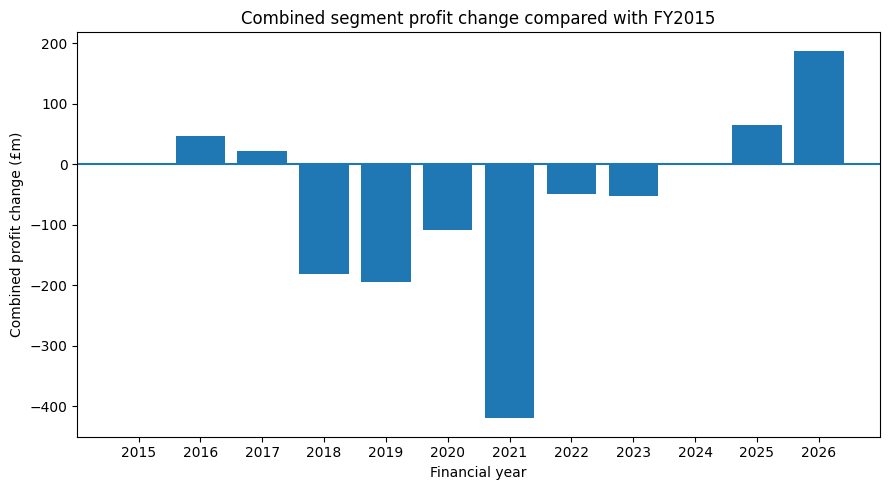

In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    compensation['FY'].astype(str),
    compensation['Combined profit change £m'])

plt.axhline(0)

plt.title('Combined segment profit change compared with FY2015')
plt.xlabel('Financial year')
plt.ylabel('Combined profit change (£m)')

plt.tight_layout()

plt.savefig(
    'Figure_4_6_profit_compensation.png',
    dpi=300)

plt.show()

In [26]:
# Compensation multiple. How many pounds of Online profit growth per pound of
# Retail profit lost. Reported across three windows because FY2015 and FY2026
# Online profit are not on the same reporting basis, as noted in section 3.3.2.

window_names = ['FY2015 to FY2026, mixed reporting basis',
                'FY2018 to FY2026, after Finance separation',
                'FY2023 to FY2026, after Total Platform removed']

start_years = [2015, 2018, 2023]
end_years = [2026, 2026, 2026]

for i in range(len(window_names)):
    window = data[(data['FY'] >= start_years[i]) & (data['FY'] <= end_years[i])]

    retail_change = window['Retail operating profit £m'].iloc[-1] - window['Retail operating profit £m'].iloc[0]
    online_change = window['Online/Directory operating profit £m'].iloc[-1] - window['Online/Directory operating profit £m'].iloc[0]

    multiple = online_change / abs(retail_change)

    print(window_names[i])
    print('   Retail change', round(retail_change, 1), '£m')
    print('   Online change', round(online_change, 1), '£m')
    print('   Compensation multiple', round(multiple, 2))
    print()

FY2015 to FY2026, mixed reporting basis
   Retail change -157.8 £m
   Online change 345.2 £m
   Compensation multiple 2.19

FY2018 to FY2026, after Finance separation
   Retail change -42.7 £m
   Online change 412.2 £m
   Compensation multiple 9.65

FY2023 to FY2026, after Total Platform removed
   Retail change -14.0 £m
   Online change 255.0 £m
   Compensation multiple 18.21



Objective 3: Online share and profitability

Creating the profitability correlation table

In [27]:
profit_correlation = data[
    [
        'Online/Directory sales share %',
        'NEXT Group PBT Margin APM %',
        'Retail profit margin %',
        'Online/Directory profit margin %']].corr()
profit_correlation.round(3)

,Online/Directory sales share %,NEXT Group PBT Margin APM %,Retail profit margin %,Online/Directory profit margin %
Online/Directory sales share %,1.000,-0.761,-0.585,-0.672
NEXT Group PBT Margin APM %,-0.761,1.000,0.915,0.459
Retail profit margin %,-0.585,0.915,1.000,0.140
Online/Directory profit margin %,-0.672,0.459,0.140,1.000


Calculating the main correlation and p-value

In [28]:
main_r, main_p = pearsonr(
    data['Online/Directory sales share %'],
    data['NEXT Group PBT Margin APM %'])

print('Correlation:', round(main_r, 4))

print('P-value:',
    round(main_p, 4))

Correlation: -0.7613
P-value: 0.004


Running the regression using all 12 years

Online/Directory sales share is the explanatory variable. Group PBT margin is the outcome variable.

In [29]:
X = data[
    ['Online/Directory sales share %']]

X = sm.add_constant(X)
y = data['NEXT Group PBT Margin APM %']
model_all_years = sm.OLS(
    y,
    X).fit()
print(model_all_years.summary())

                                 OLS Regression Results                                
Dep. Variable:     NEXT Group PBT Margin APM %   R-squared:                       0.580
Model:                                     OLS   Adj. R-squared:                  0.538
Method:                          Least Squares   F-statistic:                     13.79
Date:                         Wed, 23 Sep 2026   Prob (F-statistic):            0.00402
Time:                                 00:01:11   Log-Likelihood:                -23.147
No. Observations:                           12   AIC:                             50.29
Df Residuals:                               10   BIC:                             51.26
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------

Running the sensitivity model without FY2021

This repeats the regression after removing the COVID-disrupted year.

In [30]:
data_no_2021 = data[
    data['FY'] != 2021].copy()

X_no_2021 = data_no_2021[
    ['Online/Directory sales share %']]
X_no_2021 = sm.add_constant(
    X_no_2021)
y_no_2021 = data_no_2021[
    'NEXT Group PBT Margin APM %']
model_no_2021 = sm.OLS(
    y_no_2021,
    X_no_2021).fit()
print(model_no_2021.summary())

                                 OLS Regression Results                                
Dep. Variable:     NEXT Group PBT Margin APM %   R-squared:                       0.756
Model:                                     OLS   Adj. R-squared:                  0.728
Method:                          Least Squares   F-statistic:                     27.83
Date:                         Wed, 23 Sep 2026   Prob (F-statistic):           0.000510
Time:                                 00:01:11   Log-Likelihood:                -11.405
No. Observations:                           11   AIC:                             26.81
Df Residuals:                                9   BIC:                             27.61
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------

Comparing the two regression models

This creates a simpler table than the full Statsmodels outputs.

In [31]:
regression_comparison = pd.DataFrame({
    'Model': [
        'All 12 years',
        'FY2021 excluded'],
'Online share coefficient': [
        model_all_years.params[
            'Online/Directory sales share %'],
model_no_2021.params[
            'Online/Directory sales share %']],
'P-value': [
        model_all_years.pvalues[
            'Online/Directory sales share %'],
model_no_2021.pvalues[
            'Online/Directory sales share %']],
'R-squared': [
        model_all_years.rsquared,
        model_no_2021.rsquared]})

regression_comparison.round(4)

,Model,Online share coefficient,P-value,R-squared
0,All 12 years,-0.172,0.0040,0.5796
1,FY2021 excluded,-0.111,0.0005,0.7556


Plotting the regression relationship

This graph marks FY2021 separately and draws the fitted line from the model excluding FY2021.

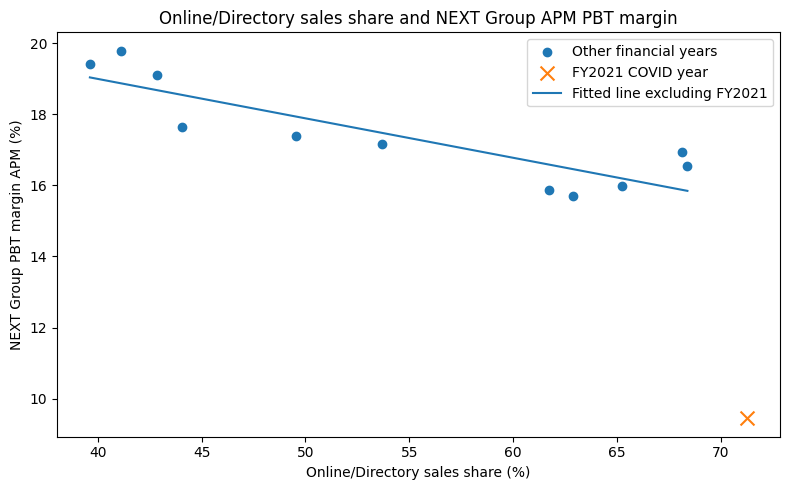

In [32]:
plot_data = data_no_2021.sort_values(
    'Online/Directory sales share %').copy()

X_plot = plot_data[
    ['Online/Directory sales share %']]

X_plot = sm.add_constant(X_plot)

plot_data['Predicted Group margin'] = (
    model_no_2021.predict(X_plot))

covid_year = data[
    data['FY'] == 2021]

plt.figure(figsize=(8, 5))

plt.scatter(
    data_no_2021['Online/Directory sales share %'],
    data_no_2021['NEXT Group PBT Margin APM %'],
    label='Other financial years')

plt.scatter(
    covid_year['Online/Directory sales share %'],
    covid_year['NEXT Group PBT Margin APM %'],
    marker='x',
    s=100,
    label='FY2021 COVID year')

plt.plot(
    plot_data['Online/Directory sales share %'],
    plot_data['Predicted Group margin'],
    label='Fitted line excluding FY2021')

plt.title(
    'Online/Directory sales share and NEXT Group APM PBT margin')

plt.xlabel(
    'Online/Directory sales share (%)')

plt.ylabel(
    'NEXT Group PBT margin APM (%)')

plt.legend()
plt.tight_layout()

plt.savefig(
    'Figure_4_7_regression_relationship.png',
    dpi=300,
    bbox_inches='tight')

plt.show()

Objective 4: Store count, distribution costs and profitability

Creating the cost and store correlation table

In [33]:
cost_store_correlation = data[
    [
        'Online/Directory sales share %',
        'Group Distribution Cost Intensity %',
        'Retail store count',
        'NEXT Group PBT Margin APM %',
        'Retail profit margin %',
        'Online/Directory profit margin %']].corr(
    method='pearson')

cost_store_correlation.round(3)

,Online/Directory sales share %,Group Distribution Cost Intensity %,Retail store count,NEXT Group PBT Margin APM %,Retail profit margin %,Online/Directory profit margin %
Online/Directory sales share %,1.000,0.985,-0.898,-0.761,-0.585,-0.672
Group Distribution Cost Intensity %,0.985,1.000,-0.926,-0.758,-0.545,-0.767
Retail store count,-0.898,-0.926,1.000,0.525,0.223,0.847
NEXT Group PBT Margin APM %,-0.761,-0.758,0.525,1.000,0.915,0.459
Retail profit margin %,-0.585,-0.545,0.223,0.915,1.000,0.140
Online/Directory profit margin %,-0.672,-0.767,0.847,0.459,0.140,1.000


Calculate Objective 4 correlations and p-values

This gives the key correlations in a clear table.

In [34]:
online_cost_r, online_cost_p = pearsonr(
    data['Online/Directory sales share %'],
    data['Group Distribution Cost Intensity %'])

cost_group_r, cost_group_p = pearsonr(
    data['Group Distribution Cost Intensity %'],
   data['NEXT Group PBT Margin APM %'])

cost_retail_r, cost_retail_p = pearsonr(
    data['Group Distribution Cost Intensity %'],
    data['Retail profit margin %'])

cost_online_r, cost_online_p = pearsonr(
    data['Group Distribution Cost Intensity %'],
    data['Online/Directory profit margin %'])

store_group_r, store_group_p = pearsonr(
    data['Retail store count'],
 data['NEXT Group PBT Margin APM %'])

store_retail_r, store_retail_p = pearsonr(
    data['Retail store count'],
    data['Retail profit margin %'])

store_online_r, store_online_p = pearsonr(
    data['Retail store count'],
    data['Online/Directory profit margin %'])

objective_4_results = pd.DataFrame({
    'Relationship': [
        'Online share and distribution-cost intensity',
        'Distribution-cost intensity and Group margin',
        'Distribution-cost intensity and Retail margin',
        'Distribution-cost intensity and Online margin',
        'Store count and Group margin',
        'Store count and Retail margin',
        'Store count and Online margin'],

    'Pearson correlation': [
        online_cost_r,
        cost_group_r,
        cost_retail_r,
        cost_online_r,
        store_group_r,
        store_retail_r,
        store_online_r],

    'P-value': [
        online_cost_p,
        cost_group_p,
        cost_retail_p,
        cost_online_p,
        store_group_p,
        store_retail_p,
        store_online_p]})

objective_4_results.round(4)

,Relationship,Pearson correlation,P-value
0,Online share and distribution-cost intensity,0.9846,0.0000
1,Distribution-cost intensity and Group margin,-0.7577,0.0043
2,Distribution-cost intensity and Retail margin,-0.5445,0.0672
3,Distribution-cost intensity and Online margin,-0.7665,0.0036
4,Store count and Group margin,0.5253,0.0794
5,Store count and Retail margin,0.2225,0.4869
6,Store count and Online margin,0.8466,0.0005


Plotting Online share against cost intensity

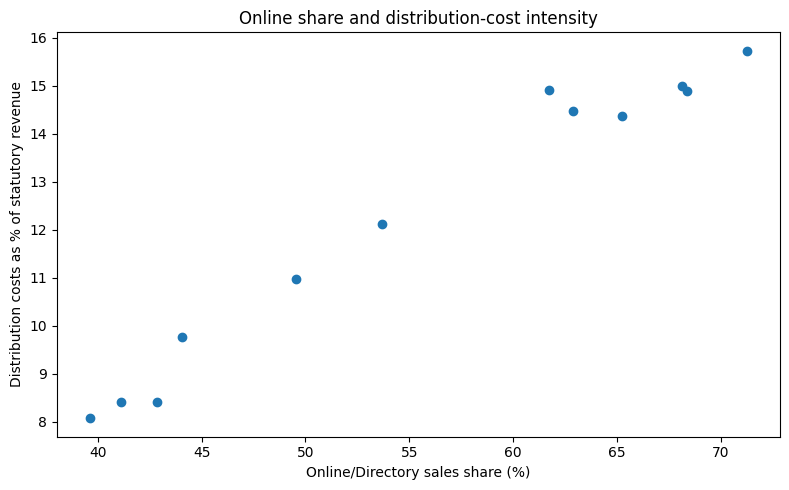

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data['Online/Directory sales share %'],
    data['Group Distribution Cost Intensity %'])

plt.title('Online share and distribution-cost intensity')
plt.xlabel('Online/Directory sales share (%)')
plt.ylabel('Distribution costs as % of statutory revenue')

plt.tight_layout()

plt.savefig(
    'Figure_4_8_online_share_and_cost.png',
    dpi=300)

plt.show()

Plotting cost intensity against Group margin

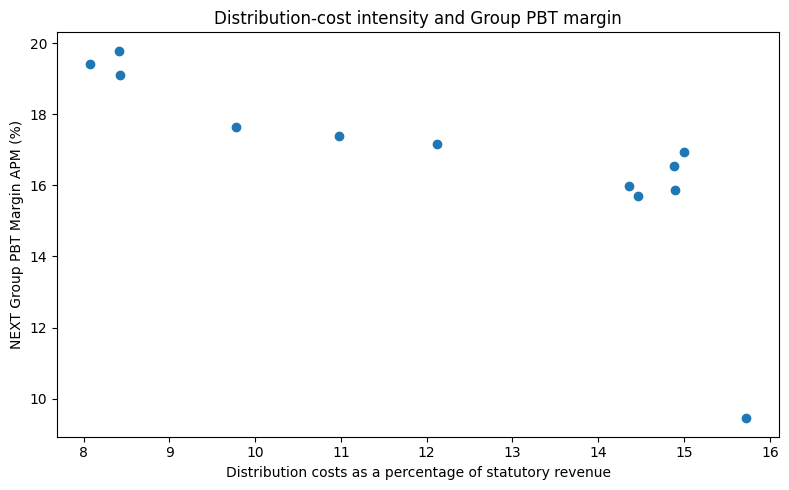

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data['Group Distribution Cost Intensity %'],
    data['NEXT Group PBT Margin APM %'])

plt.title('Distribution-cost intensity and Group PBT margin')
plt.xlabel('Distribution costs as a percentage of statutory revenue')
plt.ylabel('NEXT Group PBT Margin APM (%)')

plt.tight_layout()

plt.savefig(
    'Figure_4_9_cost_and_group_margin.png',
    dpi=300)

plt.show()

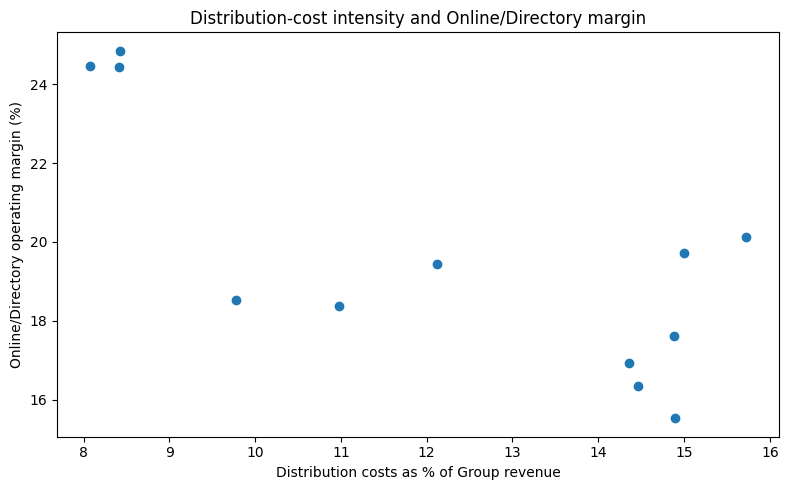

In [37]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data['Group Distribution Cost Intensity %'],
    data['Online/Directory profit margin %'])

plt.title(
    'Distribution-cost intensity and Online/Directory margin')

plt.xlabel(
    'Distribution costs as % of Group revenue')

plt.ylabel(
    'Online/Directory operating margin (%)')

plt.tight_layout()

plt.savefig(
    'Figure_4_10_cost_and_online_margin.png',
    dpi=300)

plt.show()

Plotting store count against Group margin

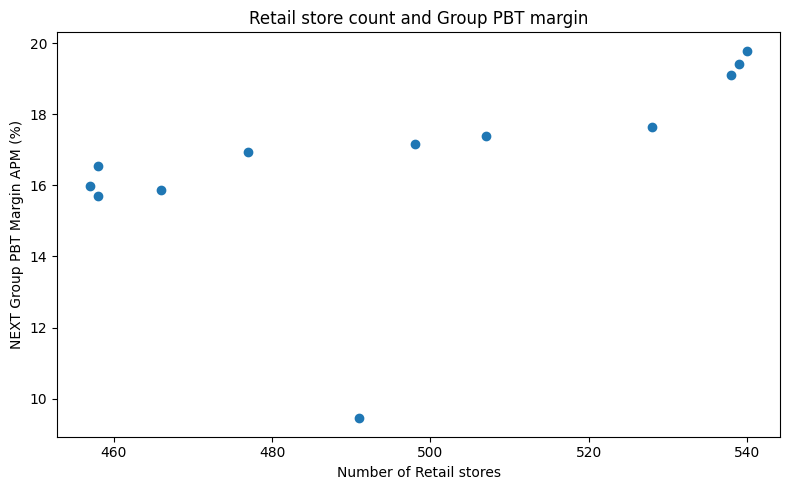

In [38]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data['Retail store count'],
    data['NEXT Group PBT Margin APM %'])

plt.title('Retail store count and Group PBT margin')
plt.xlabel('Number of Retail stores')
plt.ylabel('NEXT Group PBT Margin APM (%)')

plt.tight_layout()

plt.savefig(
    'Figure_4_10_store_count_and_margin.png',
    dpi=300)

plt.show()

Calculating annual changes in Online share and cost intensity

The full-period correlation may be high partly because both variables increase over time. This code compares their annual movements.

In [39]:
data['Change in Online share'] = data[
    'Online/Directory sales share %'
].diff()

data['Change in cost intensity'] = data[
    'Group Distribution Cost Intensity %'
].diff()

annual_cost_change = data[
    [
        'FY',
        'Change in Online share',
        'Change in cost intensity']]

annual_cost_change.round(2)

,FY,Change in Online share,Change in cost intensity
0,2015,NaN,NaN
1,2016,1.52,0.34
2,2017,1.72,0.00
3,2018,1.21,1.35
4,2019,5.47,1.21
5,2020,4.15,1.14
6,2021,17.59,3.61
7,2022,-3.13,-0.73
8,2023,-6.43,-0.10
9,2024,1.17,-0.44


Plotting annual changes in Online share and cost intensity

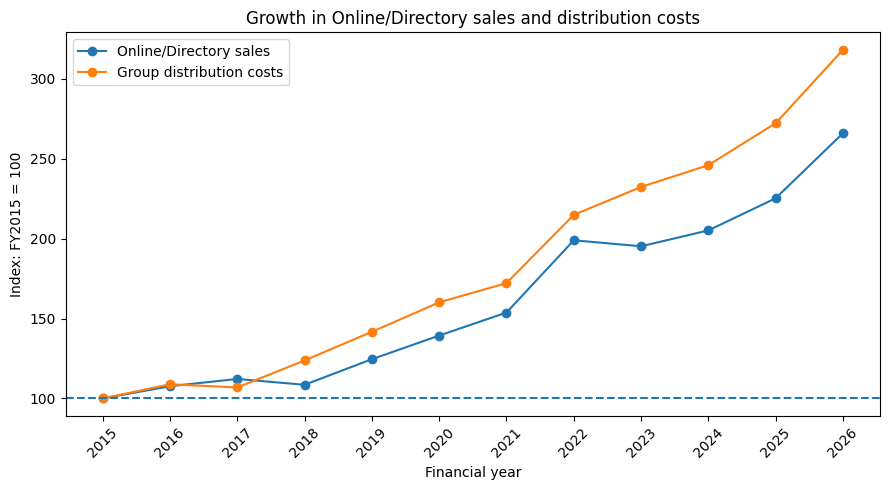

In [40]:
data['Online sales index'] = (
    data['Online/Directory sales reported £m']
    / data['Online/Directory sales reported £m'].iloc[0]) * 100

data['Distribution cost index'] = (
    data['Group Distribution Costs £m']
    / data['Group Distribution Costs £m'].iloc[0]) * 100

plt.figure(figsize=(9, 5))

plt.plot(
    data['FY'],
    data['Online sales index'],
    marker='o',
    label='Online/Directory sales')

plt.plot(
    data['FY'],
    data['Distribution cost index'],
    marker='o',
    label='Group distribution costs')

plt.axhline(
    100,
    linestyle='--')

plt.title(
    'Growth in Online/Directory sales and distribution costs')

plt.xlabel('Financial year')
plt.ylabel('Index: FY2015 = 100')

plt.xticks(
    data['FY'],
    rotation=45)

plt.legend()
plt.tight_layout()

plt.savefig(
    'Figure_4_12_indexed_sales_and_costs.png',
    dpi=300)

plt.show()

In [41]:

#Annual-Change Regression for Distribution-Cost Intensity
changes = data.dropna(subset=['Change in Online share'])

X_change = sm.add_constant(changes[['Change in Online share']])
y_change = changes['Change in cost intensity']

model_cost_change = sm.OLS(y_change, X_change).fit()

print('Change in cost intensity on change in online share')
print('   coefficient', round(model_cost_change.params['Change in Online share'], 4))
print('   p', round(model_cost_change.pvalues['Change in Online share'], 4))
print('   R2', round(model_cost_change.rsquared, 3))

Change in cost intensity on change in online share
   coefficient 0.1768
   p 0.0004
   R2 0.767


##UK supporting analysis

Importing and calculating the UK measures

In [42]:
uk_data = pd.read_excel(
    file_name,
    sheet_name='UK DATASET 2023-2026')

uk_data['UK Online sales share %'] = (
    uk_data['Online UK sales £m']
    / uk_data['UK Product sales £m']) * 100

uk_data['Retail Stores margin %'] = (
    uk_data['Retail Stores profit £m']
    / uk_data['Retail Stores sales £m']) * 100

uk_data['Online UK margin %'] = (
    uk_data['Online UK profit £m']
    / uk_data['Online UK sales £m']) * 100

uk_results = uk_data[
    [
        'FY',
        'UK Online sales share %',
        'Retail Stores margin %',
        'Online UK margin %']]

uk_results.round(2)

,FY,UK Online sales share %,Retail Stores margin %,Online UK margin %
0,2023,56.09,12.87,16.92
1,2024,56.57,13.14,17.33
2,2025,57.87,12.82,17.99
3,2026,59.66,11.94,18.71


Plotting the UK segment margins

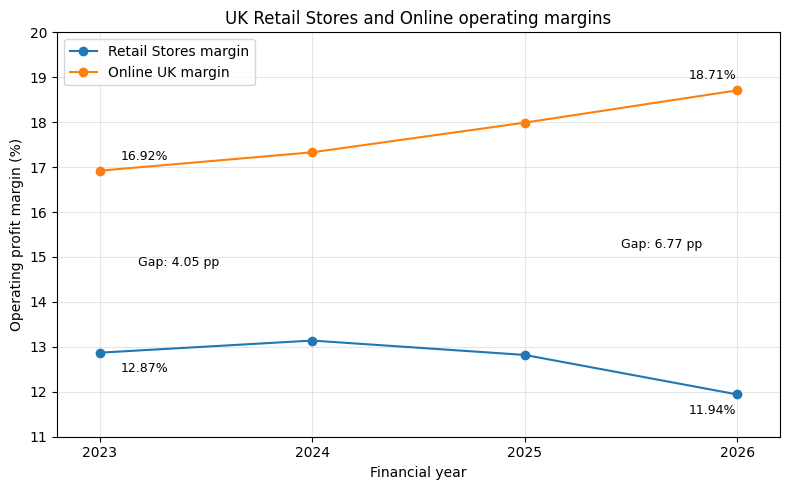

In [43]:


# Data
years = [2023, 2024, 2025, 2026]
retail_margin = [12.87, 13.14, 12.82, 11.94]
online_margin = [16.92, 17.33, 17.99, 18.71]

plt.figure(figsize=(8, 5))

# Lines
plt.plot(years, retail_margin, marker='o', label='Retail Stores margin')
plt.plot(years, online_margin, marker='o', label='Online UK margin')

# Only important value labels from the paragraph
plt.annotate('16.92%', xy=(2023, 16.92), xytext=(15, 8),
             textcoords='offset points', fontsize=9)

plt.annotate('18.71%', xy=(2026, 18.71), xytext=(-35, 8),
             textcoords='offset points', fontsize=9)

plt.annotate('12.87%', xy=(2023, 12.87), xytext=(15, -14),
             textcoords='offset points', fontsize=9)

plt.annotate('11.94%', xy=(2026, 11.94), xytext=(-35, -14),
             textcoords='offset points', fontsize=9)

# Gap labels
plt.text(2023.18, 14.8, 'Gap: 4.05 pp', fontsize=9)
plt.text(2025.45, 15.2, 'Gap: 6.77 pp', fontsize=9)

# Titles and labels
plt.title('UK Retail Stores and Online operating margins')
plt.xlabel('Financial year')
plt.ylabel('Operating profit margin (%)')

plt.xticks(years)
plt.ylim(11, 20)
plt.xlim(2022.8, 2026.2)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

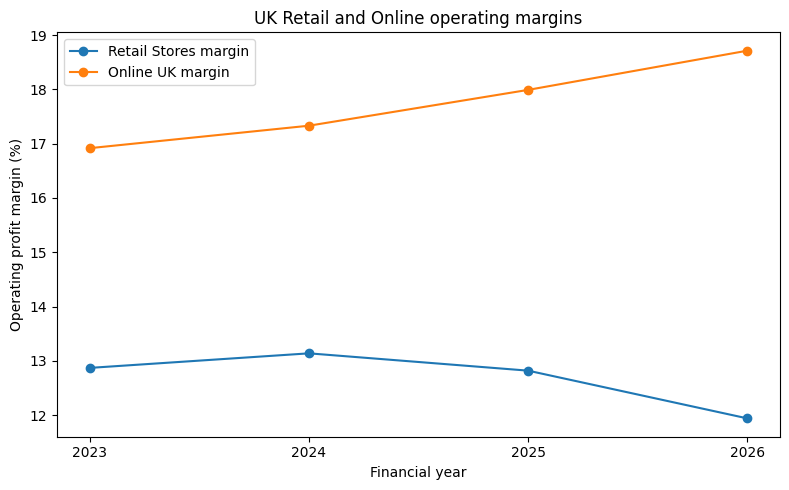

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    uk_data['FY'],
    uk_data['Retail Stores margin %'],
    marker='o',
    label='Retail Stores margin')

plt.plot(
    uk_data['FY'],
    uk_data['Online UK margin %'],
    marker='o',
    label='Online UK margin')

plt.title('UK Retail and Online operating margins')
plt.xlabel('Financial year')
plt.ylabel('Operating profit margin (%)')

plt.xticks(uk_data['FY'])
plt.legend()
plt.tight_layout()

plt.savefig(
    'Figure_4_12_UK_margins.png',
    dpi=300)

plt.show()

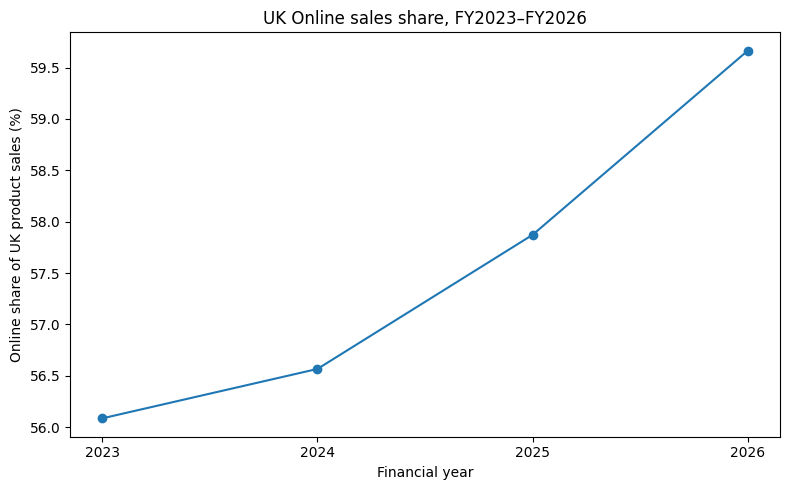

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    uk_data['FY'],
    uk_data['UK Online sales share %'],
    marker='o')

plt.title(
    'UK Online sales share, FY2023–FY2026')

plt.xlabel('Financial year')

plt.ylabel(
    'Online share of UK product sales (%)')

plt.xticks(
    uk_data['FY'])

plt.tight_layout()

plt.savefig(
    'Figure_4_13_UK_online_share.png',
    dpi=300)

plt.show()